# Loading required libraries

In [1]:
library(ggplot2)
library(patchwork)
library(scales)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(showtext)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reve

# Figures and Files Setup

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/supp_figs"

# Color palettes

In [3]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)


tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)

main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)

# Load the required data

In [4]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor_...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
celltype_percentage_exp <- read_csv(
  paste0(data_dir, "/celltype_percentage_exp.csv")) 

celltype_percentage_patient <- read_csv(
  paste0(data_dir, "/celltype_percentage_patient.csv"))

cellgroup_percentage_patient <- read_csv(
  paste0(data_dir, "/cellgroup_percentage_patient.csv"))

Rows: 375 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): patient_exp, patient_ID, cell_category_simplified, cell_category
dbl (5): cell_count, proportion, percentage, geom_mean, clr

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 233 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): patient_ID, cell_category, cell_category_simplified
dbl (2): percentage, clr

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 65 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): patient_ID, cell_category_simplified
dbl (2): percentage, clr

ℹ Use `spec()` to retrieve the full column speci

In [6]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

# Supp - Fig 1

## A

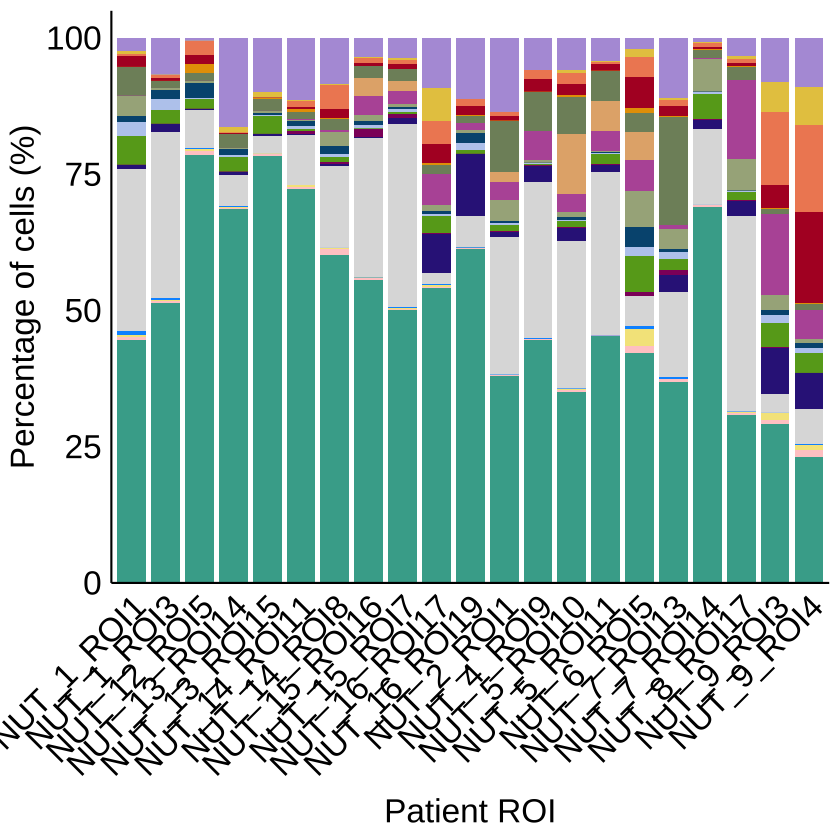

In [12]:
celltype_percentage_exp_plot = ggplot(
  celltype_percentage_exp,
  aes(x = patient_exp, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Patient ROI",
    y = "Percentage of cells (%)",
    fill = "Cell type"
  ) +
  scale_y_continuous(limits = c(0, 105), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 20, colour = "black"),
    axis.text.x = element_text(size = 20, colour = "black", angle = 45, hjust = 1),
    axis.title.y = element_text(size = 20, colour = "black"),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    axis.ticks.y.right = element_blank(),
    axis.title.y.right = element_blank(),
    axis.text.y.right = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
  )
celltype_percentage_exp_plot
ggsave(filename = file.path(results_dir, "celltype_percentage_exp_barplot.pdf"),
       plot = celltype_percentage_exp_plot,
       width = 12,
       height = 7,
       dpi = 300)

## B

In [13]:
# Pivot to wide: rows = cell_category, columns = patient_exp
clr_wide <- celltype_percentage_exp %>%
  select(patient_exp, cell_category, clr) %>%
  pivot_wider(names_from = patient_exp, values_from = clr)  %>%
  column_to_rownames("cell_category")

# Pearson correlation matrix (patient_exp x patient_exp)
cor_matrix <- cor(clr_wide, method = "pearson", use = "pairwise.complete.obs")

diag(cor_matrix) <- NA

cor_matrix

,NUT_1_ROI1,NUT_1_ROI3,NUT_2_ROI1,NUT_4_ROI9,NUT_5_ROI10,NUT_5_ROI11,NUT_6_ROI5,NUT_7_ROI13,NUT_7_ROI14,NUT_8_ROI17,⋯,NUT_9_ROI4,NUT_12_ROI5,NUT_13_ROI14,NUT_13_ROI15,NUT_14_ROI8,NUT_14_ROI11,NUT_15_ROI7,NUT_15_ROI16,NUT_16_ROI17,NUT_16_ROI19
NUT_1_ROI1,NA,0.9085201,0.6609688,0.5242908,0.6322556,0.6400650,0.6537887,0.8043603,0.7342730,0.5716556,⋯,0.5324281,0.6346042,0.8118135,0.7489088,0.6750155,0.6539984,0.5776367,0.5206734,0.4688476,0.5625282
NUT_1_ROI3,0.9085201,NA,0.6451111,0.4957445,0.6150304,0.6126215,0.5359403,0.7705642,0.6715229,0.4777471,⋯,0.4960590,0.6931719,0.8557214,0.7607970,0.7152730,0.7852497,0.5969969,0.5333826,0.4435147,0.6932254
NUT_2_ROI1,0.6609688,0.6451111,NA,0.8648839,0.8359439,0.8332443,0.7119107,0.9021299,0.7085569,0.8232979,⋯,0.4240585,0.5097280,0.5947922,0.6035904,0.8363144,0.7104199,0.8494132,0.8408333,0.5521982,0.8253993
NUT_4_ROI9,0.5242908,0.4957445,0.8648839,NA,0.9355442,0.9171080,0.5798688,0.8079718,0.6621796,0.8836459,⋯,0.6359143,0.3917457,0.4866176,0.5706408,0.6990945,0.5938005,0.8177781,0.7430097,0.7805457,0.7289803
NUT_5_ROI10,0.6322556,0.6150304,0.8359439,0.9355442,NA,0.9266066,0.7362747,0.8447429,0.7545427,0.9018463,⋯,0.6759668,0.5521629,0.6311058,0.7097897,0.7809183,0.7320849,0.9008630,0.7872584,0.8123951,0.7700335
NUT_5_ROI11,0.6400650,0.6126215,0.8332443,0.9171080,0.9266066,NA,0.6820342,0.8582392,0.6984325,0.8550705,⋯,0.5750439,0.4479059,0.6496670,0.6486846,0.6500278,0.6841994,0.9015555,0.7591584,0.7130690,0.6610378
NUT_6_ROI5,0.6537887,0.5359403,0.7119107,0.5798688,0.7362747,0.6820342,NA,0.6672785,0.7748539,0.7264023,⋯,0.6913228,0.6374040,0.5463564,0.6201329,0.7085515,0.5143322,0.6625630,0.5670107,0.7757544,0.7178132
NUT_7_ROI13,0.8043603,0.7705642,0.9021299,0.8079718,0.8447429,0.8582392,0.6672785,NA,0.8059494,0.7602827,⋯,0.4644673,0.5055587,0.7877045,0.7483409,0.8018109,0.7247554,0.8281391,0.7299442,0.5953873,0.7227355
NUT_7_ROI14,0.7342730,0.6715229,0.7085569,0.6621796,0.7545427,0.6984325,0.7748539,0.8059494,NA,0.7751069,⋯,0.4542352,0.6003773,0.6911902,0.7859711,0.7587698,0.6253441,0.7004844,0.5608922,0.5950775,0.6120551
NUT_8_ROI17,0.5716556,0.4777471,0.8232979,0.8836459,0.9018463,0.8550705,0.7264023,0.7602827,0.7751069,NA,⋯,0.6152261,0.3397871,0.4877251,0.6137671,0.6644143,0.5199904,0.8137369,0.7084943,0.7361031,0.6716452


In [15]:
#Build a heatmap of the correlation matrix using ComplexHeatmap
cor_matrix_main_ht <- Heatmap(cor_matrix, 
        name = "Pearson Correlation", 
        show_row_names = TRUE, 
        col = colorRamp2(c(0.7, 1), c("white", "red")),
        show_column_names = TRUE,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        row_names_gp = gpar(fontsize = 13),
        column_names_gp = gpar(fontsize = 13))
pdf(paste0(results_dir, "/patient_exp_correlation_heatmap.pdf"), width = 8, height = 6)
draw(cor_matrix_main_ht)
dev.off()


agg_record_20ed1b491d72 
                      2

In [16]:
#for cor_matrix, make every value NA except the ones whos column name and rowname has the same "NUT_"
cor_matrix_same_patient <- cor_matrix
for (i in 1:nrow(cor_matrix_same_patient)) {
  for (j in 1:ncol(cor_matrix_same_patient)) {
    if (str_extract(rownames(cor_matrix_same_patient)[i], "(?<=NUT_)\\d+") != str_extract(colnames(cor_matrix_same_patient)[j], "(?<=NUT_)\\d+")) {
      cor_matrix_same_patient[i, j] <- NA
    }
  }
}
cor_matrix_same_patient

,NUT_1_ROI1,NUT_1_ROI3,NUT_2_ROI1,NUT_4_ROI9,NUT_5_ROI10,NUT_5_ROI11,NUT_6_ROI5,NUT_7_ROI13,NUT_7_ROI14,NUT_8_ROI17,⋯,NUT_9_ROI4,NUT_12_ROI5,NUT_13_ROI14,NUT_13_ROI15,NUT_14_ROI8,NUT_14_ROI11,NUT_15_ROI7,NUT_15_ROI16,NUT_16_ROI17,NUT_16_ROI19
NUT_1_ROI1,NA,0.9085201,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_1_ROI3,0.9085201,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_2_ROI1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_4_ROI9,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_5_ROI10,NA,NA,NA,NA,NA,0.9266066,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_5_ROI11,NA,NA,NA,NA,0.9266066,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_6_ROI5,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_7_ROI13,NA,NA,NA,NA,NA,NA,NA,NA,0.8059494,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_7_ROI14,NA,NA,NA,NA,NA,NA,NA,0.8059494,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_8_ROI17,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [17]:
#Build a heatmap of the correlation matrix using ComplexHeatmap
cor_matrix_sub_ht <- Heatmap(cor_matrix_same_patient, 
        name = "Pearson Correlation", 
        #add a color palette that goes from white to red for the values of the correlation matrix, with white being 0, 0.5 and red being 1
        col = colorRamp2(c(0.7, 1), c("white", "red")),
        show_row_names = TRUE, 
        show_column_names = TRUE,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        row_names_gp = gpar(fontsize = 13),
        column_names_gp = gpar(fontsize = 13))
pdf(paste0(results_dir, "/patient_exp_correlation_same_patient_heatmap.pdf"), width = 8, height = 6)
draw(cor_matrix_sub_ht)
dev.off()

agg_record_20ed6249997f 
                      2

## C

In [18]:
#turn this into a long df: cor_matrix_same_patient
cor_matrix_same_patient_long <- as.data.frame(as.table(cor_matrix_same_patient)) %>%
  rename(patient_exp1 = Var1, patient_exp2 = Var2, correlation = Freq) %>%
  filter(!is.na(correlation)) %>%
  #extract patient_ID
    mutate(patient_ID = str_extract(patient_exp1, "NUT_\\d+")) %>%
    select(patient_ID, correlation) %>%
    distinct()
cor_matrix_same_patient_long

patient_ID,correlation
<chr>,<dbl>
NUT_1,0.9085201
NUT_5,0.9266066
NUT_7,0.8059494
NUT_9,0.8418227
NUT_13,0.9204366
NUT_14,0.8457880
NUT_15,0.9043826
NUT_16,0.6366097


In [19]:
#boxplot of cor_matrix_same_patient_long with all the values combined (so one box plot for the plot)
correlation_boxplot <- ggplot(cor_matrix_same_patient_long, aes(x = "", y = correlation)) +
  geom_boxplot(fill = "#44AA99", color = "black") +
  geom_jitter(width = 0.1, color = "black", size = 2) +
  theme_minimal() +
  labs(x = "Patient with two ROIs", y = "Pearson's correlation between the two ROIs") +
  theme(axis.text.x = element_text(color = "black", size = 13),
    axis.title.x = element_text(color = "black", size = 13, margin = margin(t = 10)),
    axis.title.y = element_text(color = "black", size = 13, margin = margin(r = 10)),
    axis.text.y = element_text(color = "black", size = 13),
    plot.title = element_text(color = "black", size = 16, hjust = 0.5, margin = margin(b = 20)),
    axis.line.x.bottom = element_line(color = "black", size = 0.8),
    axis.line.y.left = element_line(color = "black", size = 0.8))


#ggsave
ggsave(
  filename = paste0(results_dir, "/correlation_patient_exp_boxplot.pdf"),
  plot = correlation_boxplot,
  width = 3,
  height = 5,
  dpi = 300
)

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


: 

## D (extra)

In [150]:
plot_highlight <- function(df, highlight_levels, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 1,
                           pt_size_bg = 1.5, pt_size_fg = 1.5) {

  df_bg <- df %>% filter(!cell_category %in% highlight_levels)
  df_fg <- df %>% filter(cell_category %in% highlight_levels)

  # palette restricted to highlighted cells (keeps your exact colors)
  pal_hl <- full_palette[highlight_levels]
  pal_hl <- pal_hl[!is.na(pal_hl)]  # safety if some names not present

  ggplot() +
    geom_point(
      data = df_bg,
      aes(x = `Cell Center X`, y = `Cell Center Y`),
      color = bg_color,
      alpha = bg_alpha,
      size = pt_size_bg
    ) +
    geom_point(
      data = df_fg,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(
      values = pal_hl,
      breaks = highlight_levels,   # <- legend entries limited to highlighted
      drop = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}  


In [11]:
all_cells <- celltype_metadata %>%
   pull(cell_category) %>%
   unique()


for(i in c("NUT_16_ROI17", "NUT_16_ROI19")){
    df <- celltype_metadata %>% filter(patient_exp == i)
    p <- plot_highlight(df, highlight_levels = all_cells,
    bg_color = "white", pt_size_bg = 0.5, pt_size_fg = 0.5)

ggsave(
    filename = paste0(results_dir, "/", i, "_celltype_plot.pdf"),
    plot = p,
    width = 5,
    height = 5,
)
}


# Supp - Fig 2

In [9]:
#add tumor site information from survival_df
cellgroup_percentage_patient_survival <- cellgroup_percentage_patient %>%
  left_join(survival_df, by = "patient_ID") %>%
  mutate(tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")))
  cellgroup_percentage_patient_survival

patient_ID,cell_category_simplified,percentage,clr,tumor_site,survival_time_months,event,is_lung
<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>
NUT_1,NFC,30.187543,0.84268567,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,Non-immune,9.896333,-0.28438674,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,Lymphoid,3.258853,-1.44956522,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,Myeloid,8.657208,-0.41279865,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,Tumor,48.000062,1.30406495,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_2,NFC,25.373610,0.70746921,Lung,3,1,Lung
NUT_2,Non-immune,28.617642,0.82778291,Lung,3,1,Lung
NUT_2,Lymphoid,1.767815,-1.95649623,Lung,3,1,Lung
NUT_2,Myeloid,6.278476,-0.68911312,Lung,3,1,Lung


## A

In [13]:
#myeloid vs lymphoid across different sites
cellgroup_percentage_patient_survival_mvsl <- cellgroup_percentage_patient_survival %>%
  filter(cell_category_simplified %in% c("Myeloid", "Lymphoid"))
cellgroup_percentage_patient_survival_mvsl_nohepa <- cellgroup_percentage_patient_survival_mvsl %>%
  filter(tumor_site != "Extrahepatic")

Warning message in geom_beeswarm(width = 0.15, size = 2, alpha = 0.8, color = "black"):
“Ignoring unknown parameters: `width`”


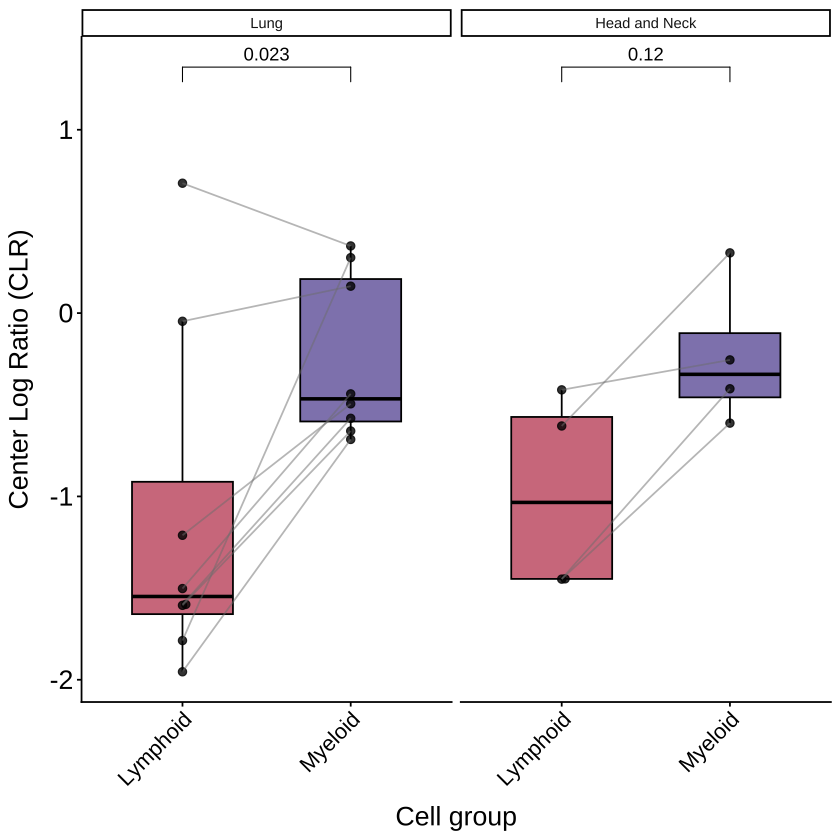

In [15]:
pd <- position_dodge(0.8)
# Nice boxplot with Wilcoxon test and medians
p <- ggplot(cellgroup_percentage_patient_survival_mvsl_nohepa, 
            aes(x = cell_category_simplified, y = clr, fill = cell_category_simplified)) +
   geom_boxplot(
    position = pd,
    width = 0.6,
    alpha = 0.6,
    color = "black",
    outlier.shape = NA
  ) +
  geom_beeswarm(
    width = 0.15,
    size = 2,
    alpha = 0.8,
    color = "black"
  ) +
  # Add Wilcoxon p-values
  stat_compare_means(
    method = "wilcox.test",
    label = "p.format",
    paired = TRUE,
    label.y = max(cellgroup_percentage_patient_survival_mvsl_nohepa$clr, na.rm = TRUE) + 0.5,
    label.x = 1.5,
    comparisons = list(c("Lymphoid", "Myeloid")),
    aes(group = cell_category_simplified, size = 13)
  ) +
    geom_line(
    aes(group = patient_ID),
    color = "grey50",
    alpha = 0.5,
    linewidth = 0.5
  ) +
  scale_fill_manual(values = main_group_colors) +
  labs(
    x = "Cell group",
    y = "Center Log Ratio (CLR)",
  ) +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
  ) +
  facet_wrap(~tumor_site, nrow = 1)
p
#save as svg
ggsave(filename = paste0(results_dir,"/myeloid_lymphoid_per_tumor_siteboxplot.pdf"),
       plot = p,
       width = 6,
       height = 5,
       dpi = 300,
       bg = "white")


In [19]:
error_bars_cellgroups_sites <- cellgroup_percentage_patient_survival_mvsl %>%
  group_by(tumor_site, cell_category_simplified) %>%
  summarise(
    mean_percentage = mean(percentage, na.rm = TRUE),
    sd_percentage = sd(percentage, na.rm = TRUE),
    n_patients = n(),
    se_percentage = sd_percentage / sqrt(n_patients),
    .groups = "drop"
  )
error_bars_cellgroups_sites

tumor_site,cell_category_simplified,mean_percentage,sd_percentage,n_patients,se_percentage
<fct>,<chr>,<dbl>,<dbl>,<int>,<dbl>
Lung,Lymphoid,8.111482,11.307491,8,3.997802
Lung,Myeloid,12.014096,7.518486,8,2.658186
Head and Neck,Lymphoid,5.328430,2.506761,4,1.253381
Head and Neck,Myeloid,10.041579,4.775193,4,2.387597
Extrahepatic,Lymphoid,4.854889,NA,1,NA
Extrahepatic,Myeloid,3.667009,NA,1,NA


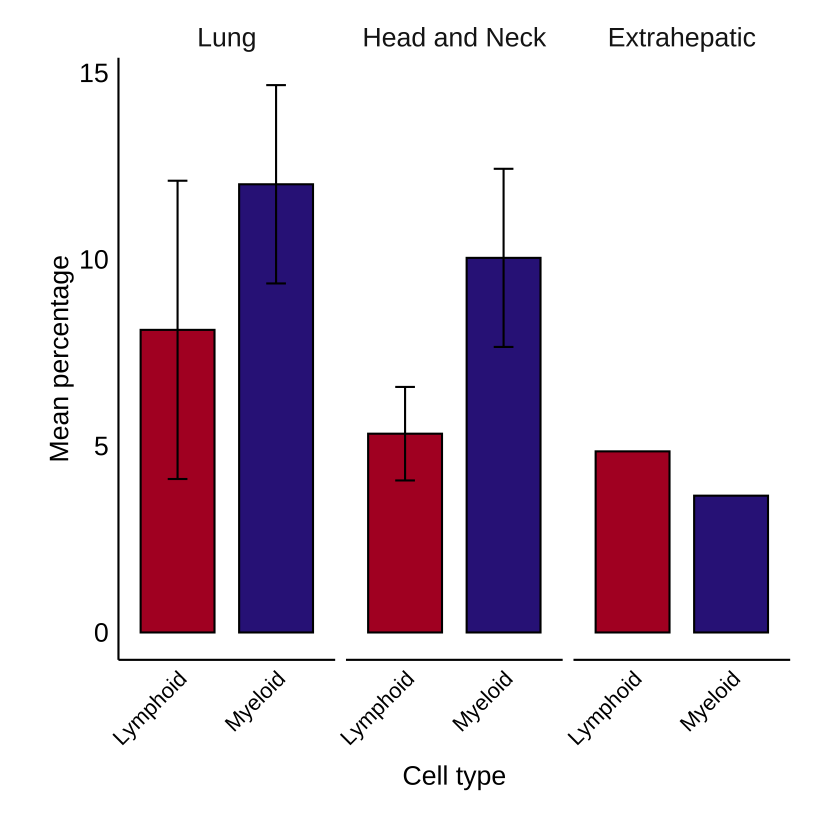

In [25]:
error_plot = ggplot(
  error_bars_cellgroups_sites,
  aes(x = cell_category_simplified, y = mean_percentage, fill = cell_category_simplified)
) +
  geom_bar(stat = "identity", width = 0.75, color = "black") +
  geom_errorbar(
    aes(ymin = mean_percentage - se_percentage,
        ymax = mean_percentage + se_percentage),
    width = 0.2
  ) +
  scale_fill_manual(values = main_group_colors) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cell type",
    y = "Mean percentage",
    fill = "Cell type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black"),
    axis.text.x = element_text(size = 13, colour = "black", angle = 45, hjust = 1),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
    strip.text = element_text(size = 16),
    plot.margin = margin(t = 10, r = 30, b = 30, l = 30)
  ) +
  facet_wrap(~ tumor_site) 

error_plot

#ggsave 
 ggsave(filename = file.path(results_dir, "cellgroups_error_bars_tumor_site.pdf"),
        plot = error_plot,
        width = 7,
        height = 5,
        dpi = 300,
        bg = "white")


## B

In [27]:
#add tumor site information from survival_df
celltype_percentage_patient_survival <- celltype_percentage_patient %>%
  left_join(survival_df, by = "patient_ID") %>%
  mutate(tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")))
celltype_percentage_patient_survival

patient_ID,cell_category,cell_category_simplified,percentage,clr,tumor_site,survival_time_months,event,is_lung
<chr>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>
NUT_1,NFC,NFC,30.18754274,3.6095581,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,Actin+ cells,Non-immune,4.58263187,1.5980359,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,Endothelial cells,Non-immune,3.26263729,1.1576057,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,Lymphatic endothelial cells,Non-immune,2.05106406,0.3272214,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,B cells,Lymphoid,0.25694590,-1.5074733,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,CD4+ T cells,Lymphoid,0.55026332,-0.3970197,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,CD8+ T cells,Lymphoid,1.21758193,0.1832241,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,NK cells,Lymphoid,0.56698361,-0.4121397,Head and Neck,170,0,Head and Neck/Extrahepatic
NUT_1,PCs,Lymphoid,0.20088303,-1.4685844,Head and Neck,170,0,Head and Neck/Extrahepatic


In [ ]:
error_bars_celltypes_sites <- celltype_percentage_patient_survival %>%
  filter(cell_category_simplified %in% c("Myeloid", "Lymphoid")) %>%
  group_by(tumor_site, cell_category, cell_category_simplified) %>%
  summarise(
    mean_percentage = mean(percentage, na.rm = TRUE),
    sd_percentage = sd(percentage, na.rm = TRUE),
    n_patients = n(),
    se_percentage = sd_percentage / sqrt(n_patients),
    .groups = "drop"
  ) %>%
  mutate(cell_category_simplified = factor(cell_category_simplified, levels = c("Myeloid, Lymphoid"))) %>%
  arrange(cell_category_simplified)

tumor_site,cell_category,cell_category_simplified,mean_percentage,sd_percentage,n_patients,se_percentage
<fct>,<chr>,<fct>,<dbl>,<dbl>,<int>,<dbl>
Lung,B cells,NA,1.40199221,2.19569070,7,0.82989308
Lung,CD4+ T cells,NA,2.93574009,4.85740416,8,1.71735171
Lung,CD8+ T cells,NA,2.70940750,3.57979091,8,1.26564721
Lung,DCs,NA,0.23784590,0.32742154,7,0.12375371
Lung,Granulocytes,NA,5.28332369,4.91413255,8,1.73740822
Lung,M1 macrophages,NA,0.83628458,1.15984320,8,0.41006650
Lung,M1/M2 macrophages,NA,0.65981778,0.56825954,8,0.20091009
Lung,M2 macrophages,NA,2.49723729,2.19133971,8,0.77475558
Lung,MDSCs,NA,2.46821512,2.45570279,7,0.92816841


In [80]:
celltype_site_barplot = ggplot(
  error_bars_celltypes_sites,
  aes(x = mean_percentage, y = tumor_site, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.3) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cell type (%)",
    y = "Tumor site",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 22), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.text.x = element_text(size = 16, colour = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
  )

ggsave(
    filename = file.path(results_dir, "celltype_site_barplot.pdf"),
    plot = celltype_site_barplot,
    dpi = 300,
    width = 6,
    height = 3
)

## C

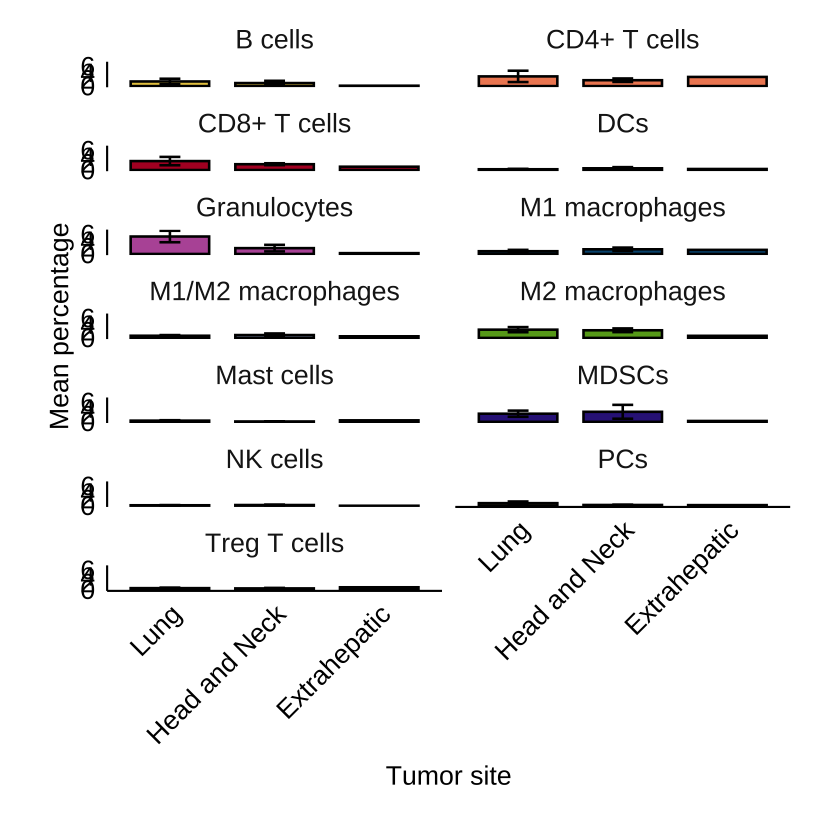

In [76]:
error_plot_by_celltypes = ggplot(
  error_bars_celltypes_sites,
  aes(x = tumor_site, y = mean_percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.75, color = "black") +
  geom_errorbar(
    aes(ymin = mean_percentage - se_percentage,
        ymax = mean_percentage + se_percentage),
    width = 0.2
  ) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Tumor site",
    y = "Mean percentage",
    fill = "Tumor site"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black"),
    axis.text.x = element_text(size = 16, colour = "black", angle = 45, hjust = 1),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_line(colour="black", linewidth=0.6),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
    strip.text = element_text(size = 16),
    plot.margin = margin(t = 10, r = 30, b = 30, l = 30)
  ) +
  facet_wrap(~ cell_category, nrow = 7) 

error_plot_by_celltypes
#ggsave 
 ggsave(filename = file.path(results_dir, "celltypes_error_bars_tumor_site.pdf"),
        plot = error_plot_by_celltypes,
        width = 10,
        height = 17,
        dpi = 300,
        bg = "white")


## D

In [83]:
for(ct in c("CD8+ T cells", "CD4+ T cells", "MDSCs", "M2 macrophages")){

df <- celltype_percentage_patient_survival %>%
filter(cell_category == ct)

#create a new column that is "High" if the percentage is above the median and "Low" if it is below the median
df <- df %>%
mutate(clr_group = factor(ifelse(is.na(clr) | clr < 0, "Low", "High"), levels = c("Low", "High")))
#perform a survival analysis using the percentage group as the variable of interest
fit <- survfit(Surv(survival_time_months, event) ~ clr_group, data = df)
# Plot
surv_plot <- ggsurvplot(
fit,
data = df,
pval = TRUE,
conf.int = TRUE,
risk.table = TRUE,
risk.table.height = 0.25,
pval.coord = c(17, 0.7),
xlim = c(0, 20),
break.time.by = 5,
palette = c("#2E86AB", "#E74C3C"),
xlab = "Time (months)",
ylab = "Survival probability",
title = paste("Survival by", ct, "proportions"),
legend.title = ct,
legend.labs = c(paste("Low", ct, "CLR"), paste("High", ct, "CLR")),
risk.table.y.text.col = TRUE,
risk.table.y.text = FALSE,
ggtheme = theme_classic(base_size = 13)
)

filename <- paste0(results_dir, "/proportions_", ct, "_CLR_survival_plot.pdf")
ggsave(
filename = filename, 
plot = surv_plot$plot, 
width = 7, 
height = 6, 
dpi = 300)
filename <- paste0(results_dir, "/proportions_", ct, "_CLR_survival_table.pdf")
ggsave(
filename = filename, 
plot = surv_plot$table, 
width = 7, 
height = 2, 
dpi = 300)
}


Ignoring unknown labels:
• colour : "CD8+ T cells"
Ignoring unknown labels:
• colour : "CD4+ T cells"
Ignoring unknown labels:
• colour : "MDSCs"
Ignoring unknown labels:
• colour : "M2 macrophages"


# Supp - Fig 3

## A

In [144]:
cluster_stability_results <- read.csv(file.path(data_dir, "cluster_stability_results.csv"))

best_k <- cluster_stability_results %>%
    filter(mean_ARI == max(mean_ARI)) %>%
    pull(k) %>%
    unique()

cluster_stability_plot <- ggplot(cluster_stability_results, aes(x = k, y = mean_ARI)) +
  geom_line(color = "darkblue", size = 1) +
  geom_point(size = 3, color = "darkblue") +
  geom_text(
    aes(label = "*", x = best_k, y = max(mean_ARI) + 0.01),
    size = 7,
    color = "black"
  ) + 
    theme_classic() +
    scale_x_continuous(limits = c(8, 19), expand = c(0, 0))+
  theme(
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
    plot.title = element_text(
      size = 20,
      hjust = 0.5  # center title
    )
  ) +
   labs(
    x = "Number of clusters k",
    y = "Mean ARI (stability)"
  ) 

ggsave(
  filename = file.path(results_dir, "cluster_stability_results_plot.pdf"),
  plot = cluster_stability_plot,
  dpi = 300,
  width = 7,
  height = 4
)

Warning message in geom_text(aes(label = "*", x = best_k, y = max(mean_ARI) + 0.01), :
“All aesthetics have length 1, but the data has 11 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”


## C

# Supp - Fig 5

## B 

In [8]:
interactions_df <- read.csv(file.path(data_dir, "myeloid_t_interactions.csv"))

In [ ]:
for(myeloid_cell in c("MDSCs", "Granulocytes", "M2 macrophages")){
for(tcell in c("CD4+ T cells", "CD8+ T cells")){
interactions_df_filtered <- interactions_df %>%
        filter(celltype_A == myeloid_cell, celltype_B == tcell) %>%
        mutate(group = factor(
    ifelse(is.na(zscore), "Low NEP", ifelse(zscore > 5, "High NEP", "Low NEP")),
    levels = c("High NEP", "Low NEP"))) %>%
    left_join(., survival_df %>% select(patient_ID, survival_time_months, event), by = "patient_ID")
     # Fit survival
    fit <- survfit(Surv(survival_time_months, event) ~ group, data = interactions_df_filtered)
  
    # Plot
    surv_plot <- ggsurvplot(
      fit,
      data = interactions_df_filtered,
      pval = TRUE,
      conf.int = TRUE,
      risk.table = TRUE,
      risk.table.height = 0.25,
      pval.coord = c(17, 0.7),
      xlim = c(0, 20),
      break.time.by = 5,
      palette = c("#E74C3C", "#2E86AB"),
      xlab = "Time (months)",
      ylab = "Survival probability",
      title = paste("Survival by", myeloid_cell, "-", tcell, "NEP"),
      legend.title = paste0(myeloid_cell, "-", tcell),
      legend.labs = c("High NEP", "Low NEP"),
      risk.table.y.text.col = TRUE,
      risk.table.y.text = FALSE,
      ggtheme = theme_classic(base_size = 13, base_family = "Arial")
    )
    filename <- paste0(results_dir, "/survival_", myeloid_cell, "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$plot, 
    width = 7, 
    height = 6, 
    dpi = 300)
    filename <- paste0(results_dir, "/survival_table_", myeloid_cell, "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$table, 
    width = 7, 
    height = 2, 
    dpi = 300)
    }
}

Ignoring unknown labels:
• colour : "MDSCs-CD4+ T cells"
Ignoring unknown labels:
• colour : "MDSCs-CD8+ T cells"
Ignoring unknown labels:
• colour : "Granulocytes-CD4+ T cells"
Ignoring unknown labels:
• colour : "Granulocytes-CD8+ T cells"
Ignoring unknown labels:
• colour : "M2 macrophages-CD4+ T cells"
Ignoring unknown labels:
• colour : "M2 macrophages-CD8+ T cells"
